
Final Results
Batch | Time: 0.5885 | Prediction: tensor([0.5000, 0.5000, 0.5000, 0.5000])
SGD | Time: 398.2545 | Prediction: tensor([0.5000, 0.5000, 0.5000, 0.5000])
MiniBatch| Time: 6.3088 | Prediction: tensor([0.5000, 0.5000, 0.5000, 0.5000])


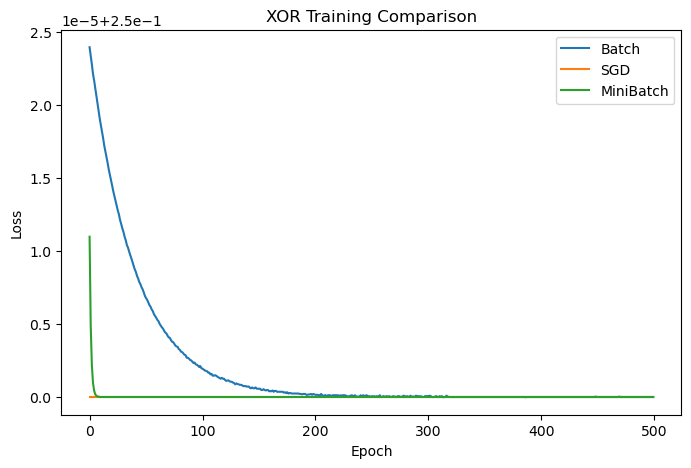

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time
import copy
torch.manual_seed(0)

# XOR dataset
X_base = torch.tensor([[0.0, 0.0],
                       [0.0, 1.0],
                       [1.0, 0.0],
                       [1.0, 1.0]])
y_base = torch.tensor([[0.0],
                       [1.0],
                       [1.0],
                       [0.0]])

# Expand dataset to increase computational load
repeat_factor = 250 # 4*250 = 1000 samples
X = X_base.repeat(repeat_factor, 1)
y = y_base.repeat(repeat_factor, 1)

# Define model with two hidden layers
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 1),
            nn.ReLU(),
            nn.Linear(1, 1),
            nn.ReLU(),
            nn.Linear(1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)
    

# Training function
def train_model(model, mode="batch", batch_size=32, lr=0.01, epochs=50):
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses = []
    start_time = time.time()

    for epoch in range(epochs):
        if mode == "batch":
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

        elif mode == "sgd":
            for i in range(len(X)):
                optimizer.zero_grad()
                output = model(X[i:i+1])
                loss = criterion(output, y[i:i+1])
                loss.backward()
                optimizer.step()

        elif mode == "minibatch":
            for i in range(0, len(X), batch_size):
                optimizer.zero_grad()
                output = model(X[i:i+batch_size])
                loss = criterion(output, y[i:i+batch_size])
                loss.backward()
                optimizer.step()

        with torch.no_grad():
            full_loss = criterion(model(X), y)
            losses.append(full_loss.item())

    total_time = time.time() - start_time

    with torch.no_grad():
        predictions = model(X_base)

    return losses, total_time, predictions


base_model = XORNet()
initial_weights = copy.deepcopy(base_model.state_dict())

EPOCHS = 500
LR = 0.1
BATCH_SIZE = 64

# Batch training
model_batch = XORNet()
model_batch.load_state_dict(initial_weights)
loss_batch, time_batch, pred_batch = train_model(model_batch, mode="batch", lr=LR, epochs=EPOCHS)

# SGD training
model_sgd = XORNet()
model_sgd.load_state_dict(initial_weights)
loss_sgd, time_sgd, pred_sgd = train_model(model_sgd, mode="sgd", lr=LR, epochs=EPOCHS)

# Mini-batch training
model_mini = XORNet()
model_mini.load_state_dict(initial_weights)
loss_mini, time_mini, pred_mini = train_model(model_mini, mode="minibatch", lr=LR, epochs=EPOCHS)

print("\nFinal Results")
print("Batch | Time:", round(time_batch,4), "| Prediction:", pred_batch.squeeze())
print("SGD | Time:", round(time_sgd,4) , "| Prediction:", pred_sgd.squeeze())
print("MiniBatch| Time:", round(time_mini,4) , "| Prediction:", pred_mini.squeeze())

plt.figure(figsize=(8, 5))
plt.plot(loss_batch, label="Batch")
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_mini, label="MiniBatch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("XOR Training Comparison")
plt.legend()
plt.show()

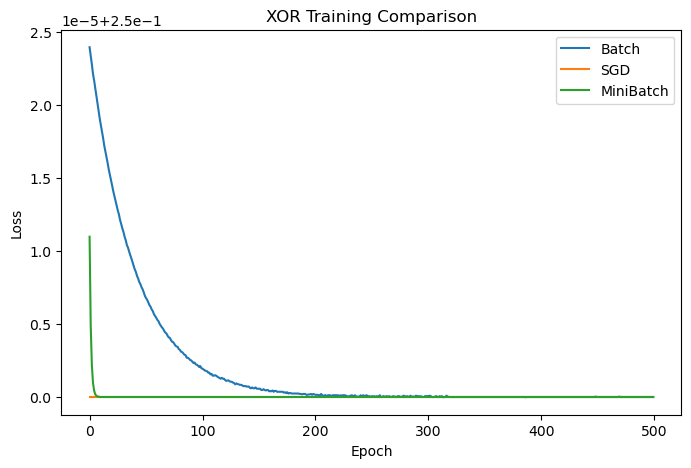

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(loss_batch, label="Batch")
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_mini, label="MiniBatch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
#plt.ylim((0, 0.001))
#plt.xlim((0, 1000))
plt.title("XOR Training Comparison")
plt.legend()
plt.show()